# Vehicle Trajectory Tracking with State-Space Modeling and MPC

This notebook walks through the project end to end:
1. Define the kinematic bicycle model (state-space form)
2. Generate a reference trajectory
3. Run closed-loop simulations with **LTV-MPC** and a **pure pursuit** baseline
4. Compare tracking performance and visualize the result

See `README.md` in the project root for the full mathematical derivation.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from vehicle_model import KinematicBicycleModel
from trajectory import get_trajectory, cumulative_arclength
from mpc_controller import MPCConfig
from baseline_controller import PurePursuitConfig
from simulate import run_mpc, run_pure_pursuit
from visualize import comparison_plot, animate_tracking

%matplotlib inline

## 1. The vehicle model

State `x = [X, Y, psi, v]`, control `u = [a, delta]`. See `KinematicBicycleModel`
in `src/vehicle_model.py` for the continuous dynamics, RK4 discretization, and the
analytic linearization used by the MPC controller at every step.

In [2]:
model = KinematicBicycleModel(wheelbase=2.7, dt=0.1)
print("min turn radius:", model.L / np.tan(model.max_steer), "m")

# sanity check: linearization matches a finite-difference Jacobian
x_bar = np.array([0.0, 0.0, 0.3, 5.0])
u_bar = np.array([0.0, 0.05])
A, B, C = model.linearize(x_bar, u_bar)
print("A =\n", np.round(A, 3))
print("B =\n", np.round(B, 3))

min turn radius: 3.8559996182037097 m
A =
 [[ 1.     0.    -0.148  0.096]
 [ 0.     1.     0.478  0.03 ]
 [ 0.     0.     1.     0.002]
 [ 0.     0.     0.     1.   ]]
B =
 [[0.    0.   ]
 [0.    0.   ]
 [0.    0.186]
 [0.1   0.   ]]


## 2. Generate a reference trajectory

Try swapping `figure_eight` for `double_lane_change` or `circular`.

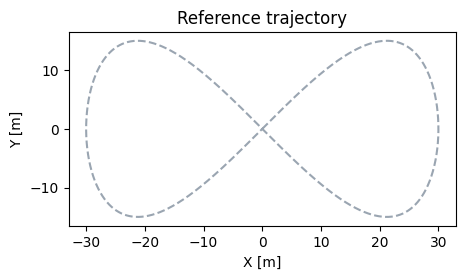

In [3]:
path = get_trajectory("figure_eight", v_target=5.0, scale=30.0)

plt.figure(figsize=(5, 5))
plt.plot(path[:, 0], path[:, 1], "--", color="#9aa5b1")
plt.gca().set_aspect("equal")
plt.title("Reference trajectory")
plt.xlabel("X [m]"); plt.ylabel("Y [m]")
plt.show()

## 3. Run closed-loop simulations: MPC vs. pure pursuit

In [4]:
x0 = np.array([path[0, 0], path[0, 1], path[0, 2], 0.0])

mpc_cfg = MPCConfig()
pp_cfg = PurePursuitConfig()

mpc_result = run_mpc(path, model, mpc_cfg, sim_time=40.0, x0=x0.copy())
pp_result = run_pure_pursuit(path, model, pp_cfg, sim_time=40.0, x0=x0.copy())

print(f"MPC  : mean|err|={np.mean(np.abs(mpc_result.lateral_error)):.3f} m, "
      f"max={np.max(np.abs(mpc_result.lateral_error)):.3f} m, "
      f"mean solve time={np.mean(mpc_result.solve_times)*1000:.2f} ms")
print(f"PP   : mean|err|={np.mean(np.abs(pp_result.lateral_error)):.3f} m, "
      f"max={np.max(np.abs(pp_result.lateral_error)):.3f} m")

MPC  : mean|err|=0.087 m, max=0.261 m, mean solve time=92.08 ms
PP   : mean|err|=0.164 m, max=0.486 m


## 4. Compare and visualize

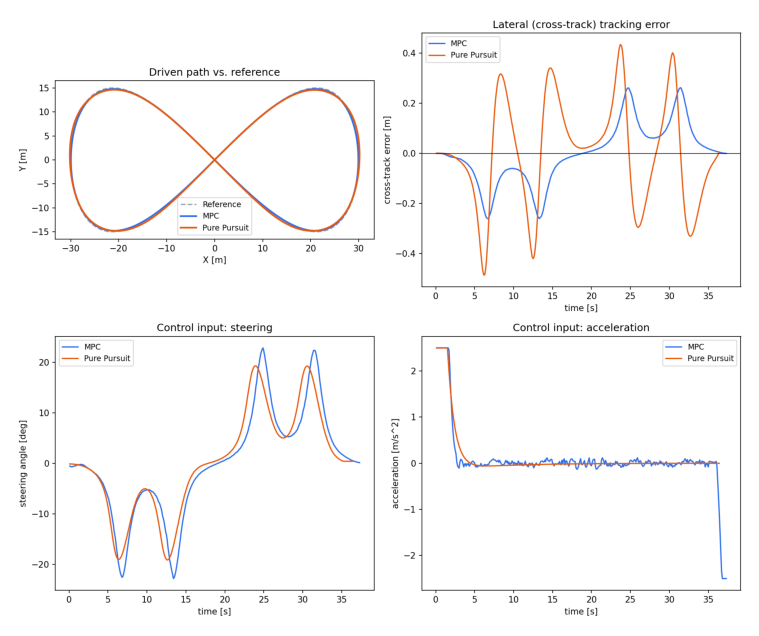

In [5]:
comparison_plot(path, mpc_result, pp_result, "../results/comparison_plot.png")
plt.figure(figsize=(10, 8))
plt.imshow(plt.imread("../results/comparison_plot.png"))
plt.axis("off")
plt.show()

Generate an animated GIF of the MPC run (with the predicted horizon overlaid) --
this writes to `../results/mpc_tracking.gif` and can take a minute or two.

In [6]:
animate_tracking(path, mpc_result, "../results/mpc_tracking.gif",
                  title="LTV-MPC tracking a figure-eight", stride=3)
print("Saved.")

Saved.


## 5. Experiment

A few things worth trying:
- Shrink `MPCConfig(horizon=...)` to 5-6 steps and re-run -- tracking should visibly degrade.
- Increase the steering rate weight `Rd` and watch the controller get more conservative.
- Try the `double_lane_change` and `circular` trajectories and compare where MPC helps most.
- Set `KinematicBicycleModel(max_steer=np.deg2rad(20))` to see how tighter actuator
  limits interact with a fixed-curvature path (this is the failure mode that motivated
  the arc-length-based reference horizon and the windowed nearest-point search in
  `trajectory.py` -- see the README for the debugging story).